Author: I. Vaimberg

Date Created: December 8, 2024

Date Updated: December 9, 2024

Notes: T. Majidzadeh added author credit, description, and relative filepath April 30, 2025 for GitHub publication.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency
import seaborn as sns

In [ ]:
path = '..\\data\\'
file_name = 'Civil Affairs Network - FINAL_December 7, 2024_14.00_v2.xlsx'

In [ ]:
all_sheets = pd.read_excel(path+file_name, sheet_name=None)

control = all_sheets['Valid Control']
treatment = all_sheets['Valid Treatment']

#need to drop first row and read in important columns and translate name

control_map = {'NQ2.4':'party','NQ2.5':'leaning','NQ2.6':'gender','NQ2.7':'age',
              'NQ2.8':'race','NQ2.9':'hispanic','NQ2.10':'citizenship',
              'Q1.1_11':'Q1','Q1.2_0':'Q2','Q1.3_0':'Q3','Q1.4_0':'Q4',
              'Q1.5_0':'Q5'}

treatment_map = {'NQ2.4':'party','NQ2.5':'leaning','NQ2.6':'gender','NQ2.7':'age',
                 'NQ2.8':'race','NQ2.9':'hispanic','NQ2.10':'citizenship',
                 'Q2.1_11':'Q1','Q2.2_11':'Q2','Q2.3_11':'Q3','Q2.4_1':'Q4',
                 'Q2.5_11':'Q5'}

control_cols = list(control_map.keys())
treatment_cols = list(treatment_map.keys())

question_cols = ['Q{}'.format(num) for num in range(1,6)]
covariates = ['party','leaning','gender','age','race','hispanic','citizenship']

clean_control = control[control_cols].rename(columns=control_map).drop(index=0).reset_index(drop=True)
clean_treatment = treatment[treatment_cols].rename(columns=treatment_map).drop(index=0).reset_index(drop=True)

clean_control['is_treatment'] = 0
clean_treatment['is_treatment'] = 1

total_responses = pd.concat([clean_control,clean_treatment])

total_responses['average_score'] = total_responses[question_cols].sum(axis=1)/5.0

total_responses.head()

,party,leaning,gender,age,race,hispanic,citizenship,Q1,Q2,Q3,Q4,Q5,is_treatment,average_score
0,Republican,Moderate,man,25-34,Black or African American,No,U.S. citizen,40,41,36,33,51,0,40.2
1,Independent,Liberal,man,35-44,American Indian or Alaska Native,No,U.S. citizen,56,54,70,35,86,0,60.2
2,Republican,Strongly Conservative,woman,45-54,White,No,U.S. citizen,100,100,100,78,100,0,95.6
3,Republican,Strongly Conservative,man,35-44,White,No,U.S. citizen,6,4,1,2,2,0,3.0
4,Republican,Moderate,man,35-44,Black or African American,No,U.S. citizen,79,72,34,100,59,0,68.8


In [ ]:
for q in question_cols:
    total_responses[q] = total_responses[q].astype(float)

In [ ]:
total_responses.dtypes

party                                              object
leaning                                            object
gender                                             object
age                                                object
race                                               object
hispanic                                           object
citizenship                                        object
Q1                                                float64
Q2                                                float64
Q3                                                float64
Q4                                                float64
Q5                                                float64
is_treatment                                        int64
average_score                                     float64
party_Independent                                   uint8
party_Other                                         uint8
party_Republican                                    uint8
leaning_Conser

## Covariate balance Check

In [ ]:


for c in covariates:
    print(f'\nChi-square Test for {c}:')
    contingency_table = pd.crosstab(total_responses['is_treatment'], total_responses[c])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi2 Statistic: {chi2}')
    print(f'p-value: {p}')
    if p < 0.05:
        print(f'The distribution of {c} is significantly different between treatment and control groups.')
    else:
        print(f'The distribution of {c} is not significantly different between treatment and control groups.')



Chi-square Test for party:
Chi2 Statistic: 1.3737556561085973
p-value: 0.711697916100247
The distribution of party is not significantly different between treatment and control groups.

Chi-square Test for leaning:
Chi2 Statistic: 1.6856511095317066
p-value: 0.9462236435924946
The distribution of leaning is not significantly different between treatment and control groups.

Chi-square Test for gender:
Chi2 Statistic: 0.08000800080008001
p-value: 0.7772865686501679
The distribution of gender is not significantly different between treatment and control groups.

Chi-square Test for age:
Chi2 Statistic: 2.8144855144855145
p-value: 0.728560323624925
The distribution of age is not significantly different between treatment and control groups.

Chi-square Test for race:
Chi2 Statistic: 6.950915750915751
p-value: 0.3254103659188367
The distribution of race is not significantly different between treatment and control groups.

Chi-square Test for hispanic:
Chi2 Statistic: 0.0
p-value: 1.0
The dist

## Modeling

In [ ]:
# turn covariates into one hot encoded columns
df_dummy = pd.get_dummies(total_responses[covariates])

one_hot_covariates = [#'party_Democrat',
 'party_Independent', 'party_Other',
'party_Republican',

'leaning_Conservative', 'leaning_Lean Conservative',
'leaning_Lean Liberal', 'leaning_Liberal', 'leaning_Moderate',
'leaning_Strongly Conservative',
 #'leaning_Strongly Liberal',

#'gender_man',
 'gender_woman',

#'age_18-24',
'age_25-34', 'age_35-44',
'age_45-54', 'age_55-64', 'age_65 or older',

'race_American Indian or Alaska Native', 'race_Asian',
'race_Black or African American',
'race_Native Hawaiian or Other Pacific Islander', 'race_Other race',
'race_Two or more',
#'race_White',

#'hispanic_No',
 'hispanic_Yes',

'citizenship_Lawful Permanent Resident',
'citizenship_Naturalized U.S. citizen',
'citizenship_Not a U.S. citizen'#,
#'citizenship_U.S. citizen'
]


total_responses[one_hot_covariates] = df_dummy[one_hot_covariates]

#interaction effects

total_responses['Democrat_x_treatment'] = total_responses['party_Democrat']*total_responses['is_treatment']
total_responses['Republican_x_treatment'] = total_responses['party_Republican']*total_responses['is_treatment']
total_responses['Independent_x_treatment'] = total_responses['party_Independent']*total_responses['is_treatment']
total_responses['Other_x_treatment'] = total_responses['party_Other']*total_responses['is_treatment']

# total_responses['pr_x_treatment'] = total_responses['citizenship_Lawful Permanent Resident']*total_responses['is_treatment']
# total_responses['nat_x_treatment'] = total_responses['citizenship_Naturalized U.S. citizen']*total_responses['is_treatment']
# total_responses['not_x_treatment'] = total_responses['citizenship_Not a U.S. citizen']*total_responses['is_treatment']

total_responses['sc_x_treatment'] = total_responses['leaning_Strongly Conservative']*total_responses['is_treatment']
total_responses['c_x_treatment'] = total_responses['leaning_Conservative']*total_responses['is_treatment']
total_responses['lc_x_treatment'] = total_responses['leaning_Lean Conservative']*total_responses['is_treatment']
total_responses['m_x_treatment'] = total_responses['leaning_Moderate']*total_responses['is_treatment']
total_responses['ll_x_treatment'] = total_responses['leaning_Lean Liberal']*total_responses['is_treatment']
total_responses['l_x_treatment'] = total_responses['leaning_Liberal']*total_responses['is_treatment']


# interaction_cols = ['pr_x_treatment','nat_x_treatment','not_x_treatment']


interaction_cols = [#'Democrat_x_treatment',
                    'Republican_x_treatment','Independent_x_treatment','Other_x_treatment']
#interaction_cols = ['sc_x_treatment','c_x_treatment','lc_x_treatment','m_x_treatment','ll_x_treatment','l_x_treatment']



In [ ]:
new_covariates = [#'party_Democrat',
 'party_Independent', 'party_Other',
'party_Republican',

'leaning_Conservative', 'leaning_Lean Conservative',
'leaning_Lean Liberal', 'leaning_Liberal', 'leaning_Moderate',
'leaning_Strongly Conservative',
 #'leaning_Strongly Liberal',

#'gender_man',
 'gender_woman',

#'age_18-24',
'age_25-34', 'age_35-44',
'age_45-54', 'age_55-64', 'age_65 or older',

'race_American Indian or Alaska Native', 'race_Asian',
'race_Black or African American',
'race_Native Hawaiian or Other Pacific Islander', 'race_Other race',
'race_Two or more',
#'race_White',

#'hispanic_No',
 'hispanic_Yes',

'citizenship_Lawful Permanent Resident',
'citizenship_Naturalized U.S. citizen',
'citizenship_Not a U.S. citizen'#,
#'citizenship_U.S. citizen'
]

/var/folders/_2/sghscg815hxgn272n9dx6tq00000gn/T/ipykernel_11221/1763057881.py:1: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(
/var/folders/_2/sghscg815hxgn272n9dx6tq00000gn/T/ipykernel_11221/1763057881.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


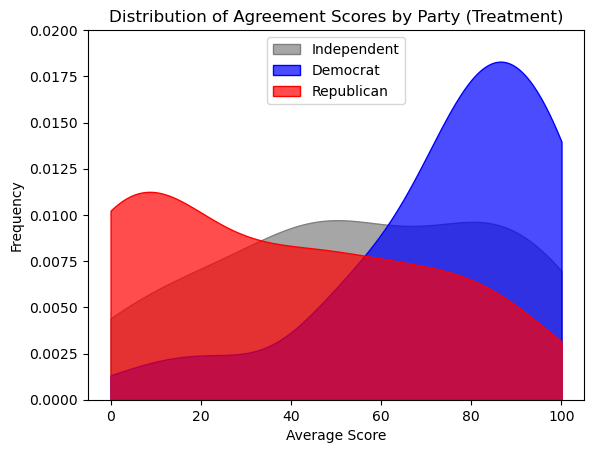

In [ ]:
sns.kdeplot(
    data=total_responses[total_responses.is_treatment == 1],
    x='average_score',
    hue='party',
    fill=True,
    alpha=0.7,  # Transparency of the fills
    clip=[0,100],
    common_norm=False,  # Ensures each distribution is normalized separately
    palette=['Red','Blue','Gray']
)

# Customize the plot
plt.title('Distribution of Agreement Scores by Party (Treatment)')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.ylim([0,.02])
plt.legend(['Independent','Democrat','Republican'],loc='upper center')
plt.show()

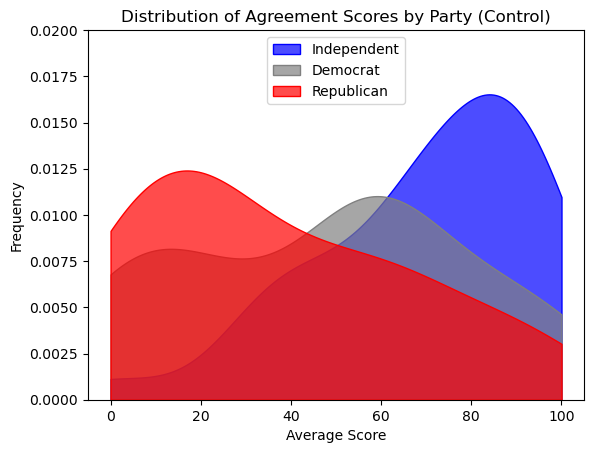

In [ ]:
sns.kdeplot(
    data=total_responses[total_responses.is_treatment == 0],
    x='average_score',
    hue='party',
    fill=True,
    alpha=0.7,  # Transparency of the fills
    clip=[0,100],
    common_norm=False,  # Ensures each distribution is normalized separately
    palette=['Red','Gray','Blue']
)

# Customize the plot
plt.title('Distribution of Agreement Scores by Party (Control)')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.ylim([0,.02])
plt.legend(['Independent','Democrat','Republican'],loc='upper center')
plt.show()

Basic Model with only simple effect of the treatment

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates]#+interaction_cols]
y = rs['average_score']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())


X_inter = rs[['is_treatment']+one_hot_covariates+interaction_cols]
X_inter = sm.add_constant(X_inter)
inter_model = sm.OLS(y,X_inter)
inter_results = inter_model.fit(cov_type='HC3')

print(inter_results.compare_lr_test(basic_results))

# Analysis: Party & Leaning were important covariates but on the whole survey results were not significant

                            OLS Regression Results                            
Dep. Variable:          average_score   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     7.558
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           1.56e-17
Time:                        02:42:41   Log-Likelihood:                -926.37
No. Observations:                 200   AIC:                             1907.
Df Residuals:                     173   BIC:                             1996.
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:2344: InvalidTestWarning: Likelihood Ratio test is likely invalid with robust covariance, proceeding anyway
  warnings.warn('Likelihood Ratio test is likely invalid with ' +


Text(0, 0.5, 'Residuals')

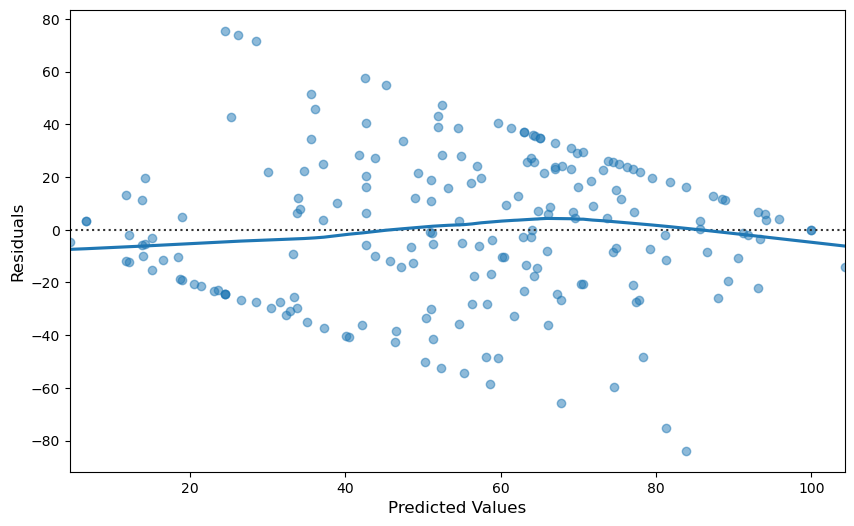

In [ ]:
# plt.scatter(basic_results.fittedvalues, basic_results.resid)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel('Fitted values')
# plt.ylabel('Residuals')
# plt.title('Residuals vs Fitted values')
# plt.show()

plt.figure(figsize=(10, 6))
sns.residplot(x=basic_results.fittedvalues, y=basic_results.resid, lowess=True, scatter_kws={'alpha': 0.5})
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)

Basic Model for Question 1

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates+interaction_cols]
y = rs['Q1']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     Q1   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     3.736
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           4.87e-08
Time:                        01:03:05   Log-Likelihood:                -947.01
No. Observations:                 200   AIC:                             1952.
Df Residuals:                     171   BIC:                             2048.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '


Basic Model for Question 2

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates+interaction_cols]
y = rs['Q2']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     5.156
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           5.06e-12
Time:                        01:03:12   Log-Likelihood:                -954.33
No. Observations:                 200   AIC:                             1967.
Df Residuals:                     171   BIC:                             2062.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '


Basic Model for Question 3

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates]
y = rs['Q3']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())



X_inter = rs[['is_treatment']+one_hot_covariates+interaction_cols]
X_inter = sm.add_constant(X_inter)
inter_model = sm.OLS(y,X_inter)
inter_results = inter_model.fit(cov_type='HC3')

print(inter_results.compare_lr_test(basic_results))

                            OLS Regression Results                            
Dep. Variable:                     Q3   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     8.409
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           1.80e-19
Time:                        01:29:36   Log-Likelihood:                -949.56
No. Observations:                 200   AIC:                             1953.
Df Residuals:                     173   BIC:                             2042.
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:2344: InvalidTestWarning: Likelihood Ratio test is likely invalid with robust covariance, proceeding anyway
  warnings.warn('Likelihood Ratio test is likely invalid with ' +


Basic Model for Question 4

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates+interaction_cols]
y = rs['Q4']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     Q4   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     7.655
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           2.17e-18
Time:                        01:05:12   Log-Likelihood:                -954.73
No. Observations:                 200   AIC:                             1967.
Df Residuals:                     171   BIC:                             2063.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '


Basic Model for Question 5

In [ ]:
rs = total_responses


X = rs[['is_treatment']+one_hot_covariates+interaction_cols]
y = rs['Q5']


X = sm.add_constant(X)
basic_model = sm.OLS(y,X)
basic_results = basic_model.fit(cov_type='HC3')
print(basic_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     Q5   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     5.678
Date:                Mon, 09 Dec 2024   Prob (F-statistic):           2.01e-13
Time:                        01:05:20   Log-Likelihood:                -948.85
No. Observations:                 200   AIC:                             1956.
Df Residuals:                     171   BIC:                             2051.
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/Users/ianvaimberg/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '
